<a href="https://colab.research.google.com/github/JUANOSORIOG/Senales_y_Sistemas/blob/main/Punto_3_Actividades.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install control matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 13.3 MB/s eta 0:00:00


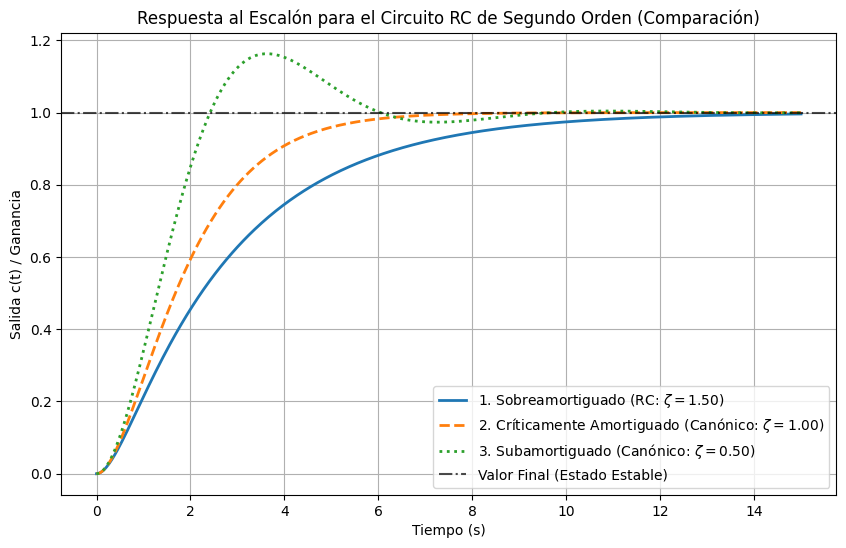


--- Valores de Amortiguamiento ---
Caso Sobreamortiguado (RC): ζ = 1.50
Caso Críticamente Amortiguado (Canónico): ζ = 1.00
Caso Subamortiguado (Canónico): ζ = 0.50


In [3]:


import numpy as np
import control # Changed import
import matplotlib.pyplot as plt

# Definición de la Función de Transferencia (FT) del Circuito RC Pasivo
# G(s) = 1 / (R1*C1*R2*C2*s^2 + (R1*C1 + R2*C2 + R1*C2)*s + 1)

###########################################################
# 1. CASO SOBREAMORTIGUADO (ζ > 1)
###########################################################
# Usamos componentes idénticos, lo que garantiza ζ = 1.5
R1_s, R2_s = 1000, 1000  # 1 kΩ
C1_s, C2_s = 0.001, 0.001  # 1 mF (Constante de tiempo τ = 1s)

# Coeficientes del denominador D(s) = A*s^2 + B*s + C
A_s = R1_s * C1_s * R2_s * C2_s
B_s = R1_s * C1_s + R2_s * C2_s + R1_s * C2_s
C_s = 1

G_sobre = control.TransferFunction([C_s], [A_s, B_s, C_s]) # Changed call
zeta_sobre = B_s / (2 * np.sqrt(A_s * C_s)) # Calculamos el ζ real

###########################################################
# 2. CASO CRÍTICAMENTE AMORTIGUADO (ζ = 1) - RC ideal
###########################################################
# Ya que el circuito RC pasivo no puede alcanzar ζ = 1,
# simulamos el caso CANÓNICO con ζ=1 para fines de comparación.
# Usamos una frecuencia natural (wn) igual a la del caso Sobreamortiguado para un contraste justo.
wn_ideal = 1 / np.sqrt(A_s) # wn = 1 rad/s

G_critico_ideal = control.TransferFunction([wn_ideal**2], [1, 2 * wn_ideal, wn_ideal**2]) # Changed call

###########################################################
# 3. CASO SUBAMORTIGUADO (ζ < 1) - RC ideal
###########################################################
# De igual manera, simulamos el caso CANÓNICO con ζ=0.5
zeta_sub = 0.5
G_sub_ideal = control.TransferFunction([wn_ideal**2], [1, 2 * zeta_sub * wn_ideal, wn_ideal**2]) # Changed call

###########################################################
# 4. SIMULACIÓN Y GRÁFICAS
###########################################################
tiempo = np.linspace(0, 15, 500) # Simulación de 0 a 15 segundos

# Simulación de respuesta al escalón
T_sobre, Y_sobre = control.step_response(G_sobre, tiempo)
T_critico, Y_critico = control.step_response(G_critico_ideal, tiempo)
T_sub, Y_sub = control.step_response(G_sub_ideal, tiempo)

# Gráfico
plt.figure(figsize=(10, 6))
plt.plot(T_sobre, Y_sobre, label=f'1. Sobreamortiguado (RC: $\\zeta={zeta_sobre:.2f}$)', linewidth=2)
plt.plot(T_critico, Y_critico, label=f'2. Críticamente Amortiguado (Canónico: $\\zeta=1.00$)', linestyle='--', linewidth=2)
plt.plot(T_sub, Y_sub, label=f'3. Subamortiguado (Canónico: $\\zeta=0.50$)', linestyle=':', linewidth=2)

plt.axhline(1.0, color='black', linestyle='-.', alpha=0.7, label='Valor Final (Estado Estable)')
plt.title('Respuesta al Escalón para el Circuito RC de Segundo Orden (Comparación)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Salida c(t) / Ganancia')
plt.grid(True)
plt.legend()
plt.show()

print(f"\n--- Valores de Amortiguamiento ---")
print(f"Caso Sobreamortiguado (RC): ζ = {zeta_sobre:.2f}")
print(f"Caso Críticamente Amortiguado (Canónico): ζ = 1.00")
print(f"Caso Subamortiguado (Canónico): ζ = 0.50")